<a href="https://colab.research.google.com/github/natalatatis/Household-Income-Analysis/blob/main/PROYECTO_SP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Predicción del ingreso anual del hogar con modelos de regresión
### Regression Dataset for Household Income Analysis

Este notebook documenta el flujo completo de aprendizaje automático para predecir la variable `Income` del dataset **Household Income Analysis** elegido por el grupo. La idea principal de este proyecto es comparar cinco modelos de regresión bajo las mismas condiciones y así seleccionar como ganador a el que mejor desempeño tenga.

**Resultado principal de la ejecución:** el modelo con mejor desempeño fue **Extra Trees Regressor**, por lo que también incluimos una sección específica para explicar y diagramar su arquitectura.

## Objetivo general

Construir, evaluar y comparar modelos de regresión capaces de estimar el ingreso anual de un hogar a partir de variables demográficas, laborales, familiares y de vivienda.

## Qué se busca analizar en el dataset

El dataset permite estudiar cómo distintas características del hogar se relacionan con el ingreso. En particular, se revisa:

- La calidad del dataset: columnas, tipos de datos, duplicados y valores faltantes.
- La distribución de `Income`, porque los ingresos suelen tener valores extremos.
- La utilidad de variables como educación, ocupación, experiencia laboral, tamaño del hogar, dependientes, vivienda y transporte.
- Qué modelo logra capturar mejor patrones no lineales y relaciones entre variables.

## Qué se busca con los modelos

No se busca demostrar causalidad. El propósito es predictivo: entrenar modelos que aprendan patrones estadísticos del dataset y comparar cuál predice mejor sobre datos no vistos.

Para que la comparación sea justa, todos los modelos usan el mismo:

- Dataset limpio.
- Conjunto de entrenamiento y prueba.
- Preprocesamiento.
- Métricas de evaluación.
- Transformación logarítmica del target.



## Metodología general del proyecto

El flujo del proyecto sigue una metodología de regresión supervisada:

1. **Carga del dataset:** se lee el archivo `data.csv` y se verifican sus columnas.
2. **Limpieza inicial:** se corrigen tipos de datos, espacios en texto, duplicados y valores faltantes.
3. **Análisis exploratorio básico:** se revisan dimensiones, estadísticas y distribución del ingreso.
4. **Ingeniería de características:** se crean variables derivadas que pueden aportar información adicional.
5. **División train/test:** se separa el dataset en entrenamiento y prueba usando estratificación por rangos de ingreso.
6. **Preprocesamiento:** se imputan datos faltantes, se escalan variables numéricas y se codifican variables categóricas.
7. **Entrenamiento de modelos:** se entrenan cinco modelos de regresión.
8. **Evaluación:** se comparan métricas en escala logarítmica y escala monetaria real.
9. **Diagnóstico del mejor modelo:** se revisan errores, residuos, variables importantes y arquitectura.
10. **Guardado del modelo:** se exporta el mejor pipeline completo para uso posterior.

La decisión de usar una transformación `log1p(Income)` es importante porque el ingreso presenta una distribución muy sesgada. Esta transformación reduce el impacto de valores extremadamente altos y permite evaluar mejor errores relativos.



## Diccionario breve de variables

| Variable | Tipo esperado | Descripción general |
|---|---|---|
| `Age` | Numérica | Edad de la persona de referencia del hogar. |
| `Education_Level` | Categórica | Nivel educativo alcanzado. |
| `Occupation` | Categórica | Área u ocupación principal. |
| `Number_of_Dependents` | Numérica | Número de personas dependientes en el hogar. |
| `Location` | Categórica | Tipo de ubicación o zona. |
| `Work_Experience` | Numérica | Años de experiencia laboral. |
| `Marital_Status` | Categórica | Estado civil. |
| `Employment_Status` | Categórica | Situación laboral. |
| `Household_Size` | Numérica | Cantidad de personas en el hogar. |
| `Homeownership_Status` | Categórica | Condición de vivienda propia o alquilada. |
| `Type_of_Housing` | Categórica | Tipo de vivienda. |
| `Gender` | Categórica | Género registrado. |
| `Primary_Mode_of_Transportation` | Categórica | Medio principal de transporte. |
| `Income` | Numérica | Variable objetivo: ingreso anual del hogar. |

`Income` es el target. Todas las demás variables se usan como posibles predictores.



## 1. Librerías y configuración

Las librerías se agrupan por función para que sea más fácil entender el notebook.

| Grupo | Librerías | Uso en el proyecto |
|---|---|---|
| Manejo general | `warnings`, `time`, `Path`, `OrderedDict` | Control de advertencias, tiempos de entrenamiento, rutas y orden de modelos. |
| Datos | `numpy`, `pandas` | Limpieza, tablas, operaciones numéricas y creación de variables. |
| Visualización | `matplotlib`, `seaborn` | Gráficas de distribución, comparación de modelos, residuos e importancia de variables. |
| Notebook | `display` | Mostrar tablas con mejor formato dentro del `.ipynb`. |
| Exportación | `joblib.dump` | Guardar el mejor modelo entrenado. |
| Scikit-learn | `Pipeline`, `ColumnTransformer`, modelos y métricas | Construcción del flujo completo de machine learning. |
| Modelos externos | `xgboost`, `lightgbm` | Modelos boosting opcionales si están instalados. |

Se usa `RANDOM_STATE = 42` para que las divisiones y modelos aleatorios sean reproducibles.


In [1]:
# =============================
# 1. Imports y configuración
# =============================

# Utilidades generales.
import warnings
import time
from pathlib import Path
from collections import OrderedDict

# Manejo de datos y operaciones numéricas.
import numpy as np
import pandas as pd

# Visualización. Matplotlib se usa como base para todas las gráficas.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas propias del notebook.
from IPython.display import display
from joblib import dump

# División de datos, pipelines y transformación del target.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

# Preprocesamiento de variables numéricas y categóricas.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Métricas de evaluación.
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    make_scorer,
)

# Modelos base y ensambles de scikit-learn.
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)

# XGBoost y LightGBM son opcionales. Si no están instalados, se usan alternativas.
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

# Configuración global del notebook.
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Carga del dataset

El notebook busca el archivo en tres ubicaciones comunes:

- `data.csv` en la misma carpeta del notebook.
- Ruta de Kaggle: `/kaggle/input/regression-dataset-for-household-income-analysis/data.csv`.
- Ruta local usada en este entorno: `/mnt/data/data.csv`.

La carga se hizo de forma robusta para que el notebook funcione tanto en Kaggle como en una computadora local. Si el archivo no aparece, se muestra un error claro indicando qué debe hacerse.

También se define una lista de columnas esperadas. Esto ayuda si el CSV se descarga sin encabezados o si la primera fila queda cargada incorrectamente como dato.


In [2]:
# =============================
# 2. Carga robusta del dataset
# =============================

# Columnas esperadas según la estructura del dataset.
EXPECTED_COLUMNS = [
    "Age",
    "Education_Level",
    "Occupation",
    "Number_of_Dependents",
    "Location",
    "Work_Experience",
    "Marital_Status",
    "Employment_Status",
    "Household_Size",
    "Homeownership_Status",
    "Type_of_Housing",
    "Gender",
    "Primary_Mode_of_Transportation",
    "Income",
]

# Posibles rutas del archivo. La primera que exista será usada.
candidate_paths = [
    Path("data.csv"),
    Path("/kaggle/input/regression-dataset-for-household-income-analysis/data.csv"),
    Path("/mnt/data/data.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró data.csv. Descarga el dataset desde Kaggle y colócalo "
        "en la misma carpeta del notebook, o ejecuta el notebook dentro de Kaggle "
        "agregando el dataset como input."
    )

# El dataset normalmente trae encabezados. Primero intentamos leerlo así.
df = pd.read_csv(DATA_PATH)
df.columns = [str(col).strip().replace(" ", "_") for col in df.columns]

# Si no aparece Income, asumimos que el CSV venía sin encabezados.
if "Income" not in df.columns:
    df = pd.read_csv(DATA_PATH, names=EXPECTED_COLUMNS)

# Si la fila de encabezados quedó como primer registro, se elimina.
if str(df.iloc[0]["Age"]).strip().lower() == "age":
    df = df.iloc[1:].reset_index(drop=True)

print(f"Archivo usado: {DATA_PATH}")
print(f"Dimensiones iniciales: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
display(df.head())

Archivo usado: data.csv
Dimensiones iniciales: 10,000 filas x 14 columnas


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210



## 3. Limpieza y revisión rápida

Esta etapa busca dejar el dataset en una forma confiable antes de entrenar cualquier modelo.

Lo que revisamos aquí son:

- Que las columnas numéricas realmente sean numéricas.
- Que las variables categóricas no tengan espacios innecesarios.
- Que no existan registros duplicados.
- Que la variable objetivo `Income` esté presente y no sea nula.
- Que todos los modelos trabajen con la misma versión limpia del dataset.

La limpieza se hace una sola vez. Esto evita que cada modelo reciba datos ligeramente distintos.


In [4]:
# =============================
# 3. Limpieza de datos
# =============================
df = df.copy()

# Columnas numéricas conocidas. Income es el target.
numeric_cols = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size", "Income"]
categorical_cols = [col for col in df.columns if col not in numeric_cols]

# Convertimos a numérico. Los errores pasan a NaN para detectarlos después.
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Limpiamos texto en variables categóricas.
for col in categorical_cols:
    df[col] = df[col].astype("object").where(df[col].notna(), np.nan)
    df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

# Eliminamos duplicados exactos.
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicates_removed = rows_before - len(df)

# En regresión supervisada no se puede entrenar sin target.
df = df.dropna(subset=["Income"]).reset_index(drop=True)

print(f"Duplicados eliminados: {duplicates_removed:,}")
print(f"Dimensiones después de limpieza: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print("Valores faltantes por columna:")
display(df.isna().sum().to_frame("missing_values"))

Duplicados eliminados: 0
Dimensiones después de limpieza: 10,000 filas x 14 columnas
Valores faltantes por columna:


,missing_values
Age,0
Education_Level,0
Occupation,0
Number_of_Dependents,0
Location,0
Work_Experience,0
Marital_Status,0
Employment_Status,0
Household_Size,0
Homeownership_Status,0



### Lectura de la limpieza

En la ejecución incluida, el dataset quedó con **10,000 filas y 14 columnas**, sin duplicados eliminados y sin valores faltantes. Esto es positivo porque permite concentrar el trabajo en el modelado y no en reconstruir datos incompletos.

Aun así, se mantiene el uso de imputadores dentro del pipeline. Esto es una buena práctica porque si en el futuro se usa un archivo con algún valor faltante, el modelo seguirá funcionando sin romperse.


Resumen numérico:


,count,mean,std,min,50%,75%,90%,95%,99%,max
Age,"10,000.0000",44.0217,15.2040,18.0000,44.0000,57.0000,65.0000,68.0000,70.0000,70.0000
Number_of_Dependents,"10,000.0000",2.5270,1.7140,0.0000,3.0000,4.0000,5.0000,5.0000,5.0000,5.0000
Work_Experience,"10,000.0000",24.8588,14.6526,0.0000,25.0000,37.0000,45.0000,48.0000,50.0000,50.0000
Household_Size,"10,000.0000",3.9896,2.0105,1.0000,4.0000,6.0000,7.0000,7.0000,7.0000,7.0000
Income,"10,000.0000","816,838.1667","1,821,089.3304","31,044.0000","72,943.0000","350,667.5000","2,890,510.4000","5,343,905.4500","8,836,918.8200","9,992,571.0000"


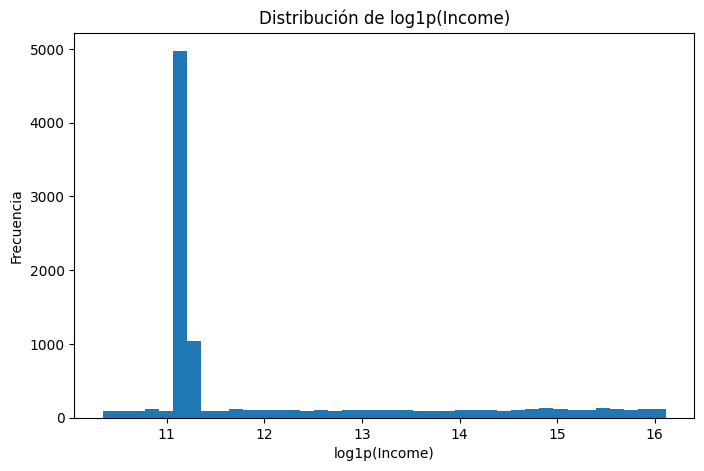

In [5]:
# Resumen de variables numéricas y distribución del ingreso.
print("Resumen numérico:")
display(df[numeric_cols].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T)

# Usamos log1p para visualizar mejor la cola larga de Income.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(df["Income"]), bins=40)
ax.set_title("Distribución de log1p(Income)")
ax.set_xlabel("log1p(Income)")
ax.set_ylabel("Frecuencia")
plt.show()


### Interpretación del análisis numérico

La variable `Income` es el punto más importante del análisis en este proyecto. En la ejecución incluida, la media del ingreso fue mucho mayor que la mediana. Esto indica una distribución sesgada hacia la derecha: muchos hogares tienen ingresos moderados, pero algunos tienen ingresos extremadamente altos.

Este comportamiento justifica dos decisiones del proyecto:

1. **Transformar el target con `log1p(Income)`** durante el entrenamiento.
2. **Usar RMSLE como métrica principal**, porque mide mejor errores relativos cuando hay valores muy grandes.

La gráfica de `log1p(Income)` permite observar la distribución de forma más estable que una gráfica directa de `Income` en dólares.



## 4. Ingeniería de características

La ingeniería de características crea nuevas variables a partir de las existentes. No se inventa información externa; solo se reorganiza información ya presente para que los modelos puedan aprender relaciones más útiles.

Variables creadas:

| Variable nueva | Idea que representa |
|---|---|
| `Experience_per_Age` | Proporción de experiencia laboral respecto a la edad. |
| `Dependents_per_Household` | Carga de dependientes dentro del tamaño total del hogar. |
| `Age_Group` | Rango de edad para capturar patrones no estrictamente lineales. |
| `Experience_Group` | Rango de experiencia laboral. |

Estas variables pueden ayudar especialmente a modelos basados en árboles, porque permiten separar mejor grupos de hogares con características similares.


In [6]:
# =============================
# 4. Feature engineering
# =============================
def add_features(X: pd.DataFrame) -> pd.DataFrame:
    """Agrega variables derivadas sin usar el target."""
    X = X.copy()

    # Relaciones simples entre variables numéricas.
    X["Experience_per_Age"] = X["Work_Experience"] / X["Age"].replace(0, np.nan)
    X["Dependents_per_Household"] = X["Number_of_Dependents"] / X["Household_Size"].replace(0, np.nan)

    # Grupos de edad. Ayudan a capturar cambios por etapas.
    X["Age_Group"] = pd.cut(
        X["Age"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
        include_lowest=True,
    ).astype("object")

    # Grupos de experiencia laboral.
    X["Experience_Group"] = pd.cut(
        X["Work_Experience"],
        bins=[-1, 5, 15, 30, 50],
        labels=["0-5", "6-15", "16-30", "31+"],
    ).astype("object")

    return X

# X contiene predictores; y contiene solo el ingreso.
X = add_features(df.drop(columns=["Income"]))
y = df["Income"].copy()

# Separamos columnas por tipo para aplicar tratamientos distintos en el pipeline.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Variables numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Variables categóricas ({len(categorical_features)}): {categorical_features}")

Variables numéricas (6): ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Experience_per_Age', 'Dependents_per_Household']
Variables categóricas (11): ['Education_Level', 'Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Gender', 'Primary_Mode_of_Transportation', 'Age_Group', 'Experience_Group']



### Resultado de la ingeniería de características

Después de crear las variables derivadas, el dataset usado por los modelos queda dividido en:

- **Variables numéricas:** variables continuas o discretas que pueden escalarse.
- **Variables categóricas:** variables de texto o grupos que deben codificarse antes del entrenamiento.

En la ejecución incluida se obtuvieron **6 variables numéricas** y **11 variables categóricas**. Más adelante, las variables categóricas se transforman con One-Hot Encoding, por lo que el número final de columnas transformadas aumenta.



## 5. Separación entrenamiento/prueba

Se usa una división **80% entrenamiento / 20% prueba**.

El conjunto de entrenamiento sirve para ajustar los modelos. El conjunto de prueba se reserva para evaluar qué tan bien generalizan con datos que no vieron durante el entrenamiento.

Como `Income` tiene valores extremos, no se usa una división completamente aleatoria sin control. Se crean deciles de ingreso con `pd.qcut` y luego se estratifica con esos deciles. Esto ayuda a que entrenamiento y prueba conserven una distribución parecida de ingresos bajos, medios y altos.


In [7]:
# =============================
# 5. Train/test split
# =============================

# Deciles de ingreso para estratificar la división.
income_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=income_bins,
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"Ingreso medio train: ${y_train.mean():,.2f}")
print(f"Ingreso medio test:  ${y_test.mean():,.2f}")

Train: 8,000 filas
Test:  2,000 filas
Ingreso medio train: $820,854.63
Ingreso medio test:  $800,772.33



## 6. Preprocesamiento y métricas

El preprocesamiento se implementa con `Pipeline` y `ColumnTransformer`. Esto es importante porque evita **data leakage**.

**Data leakage** ocurre cuando la información del conjunto de prueba se filtra al entrenamiento. Por ejemplo, si se calcula una media usando todo el dataset antes de separar train/test, el modelo ya habría recibido información indirecta del test. Con `Pipeline`, los pasos se ajustan solo con `X_train` y luego se aplican a `X_test`.

Tratamientos aplicados:

| Tipo de variable | Tratamiento | Motivo |
|---|---|---|
| Numéricas | Imputación por mediana | Robusta ante valores extremos. |
| Numéricas | `StandardScaler` | Estandariza escala para modelos sensibles a magnitudes, como Ridge. |
| Categóricas | Imputación por moda | Rellena categorías faltantes con la más frecuente. |
| Categóricas | `OneHotEncoder` | Convierte categorías en columnas numéricas binarias. |
| Target | `log1p(Income)` | Reduce el efecto de ingresos extremos. |
| Predicción | `expm1(predicción)` | Devuelve la predicción a escala monetaria. |

### Métricas usadas

| Métrica | Qué mide | Cómo interpretarla |
|---|---|---|
| `RMSLE` | Error cuadrático medio en escala logarítmica | Menor es mejor; métrica principal. |
| `R2_log` | Varianza explicada en escala logarítmica | Mayor es mejor. |
| `MAE` | Error absoluto promedio en dólares | Menor es mejor; fácil de interpretar. |
| `Median_AE` | Mediana del error absoluto | Menor es mejor; menos afectada por outliers. |
| `RMSE` | Error cuadrático medio en dólares | Penaliza más los errores grandes. |
| `R2_real` | Varianza explicada en escala real | Puede verse afectado por ingresos extremos. |


In [8]:
# =============================
# 6. Preprocesamiento y helpers
# =============================
def make_one_hot_encoder():
    """Compatibilidad con versiones nuevas y antiguas de scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Flujo para variables numéricas.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Flujo para variables categóricas.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

# ColumnTransformer aplica cada flujo a su grupo de columnas.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


def build_model(regressor):
    """Crea un pipeline completo con preprocesamiento + regresor + target log."""
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", regressor),
        ]
    )

    # El modelo aprende en escala logarítmica y predice de vuelta en dólares.
    return TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def rmsle(y_true, y_pred):
    """Root Mean Squared Log Error. Útil cuando el target tiene cola larga."""
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))


def evaluate_predictions(y_true, y_pred):
    """Devuelve métricas en escala logarítmica y escala real."""
    y_pred = np.maximum(y_pred, 0)
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)

    return {
        "R2_log": r2_score(log_true, log_pred),
        "RMSLE": rmsle(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_real": r2_score(y_true, y_pred),
    }


## 7. Definición de los 5 modelos

Se comparan cinco modelos porque cada uno representa una forma distinta de aprender patrones.

| Modelo | Tipo | Por qué se incluye |
|---|---|---|
| Ridge Regression | Lineal regularizado | Sirve como baseline sencillo y rápido. |
| Random Forest | Ensamble tipo bagging | Captura relaciones no lineales y reduce varianza. |
| Extra Trees | Ensamble de árboles muy aleatorizados | Similar a Random Forest, pero con divisiones más aleatorias; puede generalizar mejor. |
| XGBoost | Boosting secuencial | Aprende corrigiendo errores de modelos anteriores. |
| LightGBM | Boosting eficiente | Suele rendir bien en datos tabulares con buen tiempo de entrenamiento. |

### Parámetros principales usados

| Parámetro | Modelos donde aparece | Función |
|---|---|---|
| `n_estimators` | Árboles y boosting | Cantidad de árboles o estimadores. Más estimadores suelen estabilizar el modelo, pero tardan más. |
| `max_depth` | Modelos de árboles | Profundidad máxima. Controla complejidad y riesgo de sobreajuste. |
| `min_samples_split` | Random Forest / Extra Trees | Mínimo de muestras para dividir un nodo. Valores mayores hacen árboles más conservadores. |
| `min_samples_leaf` | Random Forest / Extra Trees | Mínimo de muestras en una hoja. Ayuda a evitar hojas demasiado específicas. |
| `max_features` | Random Forest / Extra Trees | Fracción de variables consideradas en cada división. Aumenta diversidad entre árboles. |
| `learning_rate` | XGBoost / LightGBM | Tamaño del ajuste de cada nuevo árbol. Valores bajos suelen requerir más árboles. |
| `reg_lambda`, `reg_alpha` | XGBoost / LightGBM | Regularización para controlar sobreajuste. |

Los valores seleccionados buscan un balance entre desempeño, estabilidad y tiempo de ejecución. La sección de tuning permite mejorarlos de forma más sistemática.


In [9]:
# =============================
# 7. Modelos
# =============================
models = OrderedDict()

# Baseline lineal regularizado.
models["Ridge"] = build_model(
    Ridge(alpha=10.0)
)

# Ensamble de árboles con bootstrap.
models["Random Forest"] = build_model(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=0.70,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

# Ensamble de árboles extremadamente aleatorizados.
models["Extra Trees"] = build_model(
    ExtraTreesRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_split=15,
        min_samples_leaf=8,
        max_features=0.80,
        bootstrap=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

# XGBoost se usa si está instalado.
if XGBRegressor is not None:
    models["XGBoost"] = build_model(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_child_weight=20,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=20,
            reg_alpha=1,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=1,      # más estable en varios entornos de notebook
            verbosity=0,
        )
    )
else:
    # Alternativa si XGBoost no está disponible.
    models["Gradient Boosting"] = build_model(
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=20,
            subsample=0.85,
            random_state=RANDOM_STATE,
        )
    )

# LightGBM se usa si está instalado.
if LGBMRegressor is not None:
    models["LightGBM"] = build_model(
        LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1,
        )
    )
else:
    # Segunda alternativa para mantener exactamente 5 modelos.
    fallback_name = "Gradient Boosting" if "Gradient Boosting" not in models else "AdaBoost"
    fallback_model = (
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=20,
            subsample=0.85,
            random_state=RANDOM_STATE,
        )
        if fallback_name == "Gradient Boosting"
        else AdaBoostRegressor(
            n_estimators=250,
            learning_rate=0.03,
            random_state=RANDOM_STATE,
        )
    )
    models[fallback_name] = build_model(fallback_model)

assert len(models) == 5, f"Se esperaban 5 modelos y se crearon {len(models)}."
print("Modelos a entrenar:")
for name in models:
    print(f"- {name}")

Modelos a entrenar:
- Ridge
- Random Forest
- Extra Trees
- XGBoost
- LightGBM



## 8. Entrenamiento y comparación

Todos los modelos se entrenan dentro del mismo ciclo. Esto evita código repetido y asegura que la evaluación sea consistente.

La tabla final se ordena por `RMSLE`, porque es la métrica principal para este problema. También se muestran métricas en dólares para que el error sea interpretable en términos reales.

Una aclaración importante: un `R2_real` bajo o negativo puede aparecer cuando el target tiene valores extremos. En este caso, no invalida toda la comparación, pero sí indica que evaluar directamente en dólares es difícil porque pocos ingresos muy altos dominan la varianza.


In [10]:
# =============================
# 8. Entrenamiento y evaluación
# =============================
fitted_models = OrderedDict()
predictions = OrderedDict()
results = []

for name, model in models.items():
    print(f"Entrenando {name}...")
    start_time = time.time()

    # El pipeline ajusta preprocesamiento y modelo usando solo train.
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Por seguridad, evitamos predicciones negativas de ingreso.
    y_pred = np.maximum(y_pred, 0)

    elapsed = time.time() - start_time
    metrics = evaluate_predictions(y_test, y_pred)
    metrics["Train_seconds"] = elapsed
    metrics["Model"] = name

    fitted_models[name] = model
    predictions[name] = y_pred
    results.append(metrics)

# Tabla de resultados ordenada por la métrica principal.
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values(by=["RMSLE", "MAE"], ascending=True)
)

# Formato amigable para lectura en el notebook.
formatted_results = results_df.copy()
for col in ["MAE", "Median_AE", "RMSE"]:
    formatted_results[col] = formatted_results[col].map(lambda x: f"${x:,.2f}")
for col in ["R2_log", "RMSLE", "R2_real", "Train_seconds"]:
    formatted_results[col] = formatted_results[col].map(lambda x: f"{x:,.4f}")

display(formatted_results)

# Selección automática del mejor modelo.
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

print(f"Mejor modelo según RMSLE: {best_model_name}")

Entrenando Ridge...
Entrenando Random Forest...
Entrenando Extra Trees...
Entrenando XGBoost...
Entrenando LightGBM...


,R2_log,RMSLE,MAE,Median_AE,RMSE,R2_real,Train_seconds
Model,,,,,,,
Extra Trees,0.2454,1.3181,"$722,780.59","$93,455.11","$1,800,558.11",-0.0468,9.1285
Random Forest,0.1977,1.3592,"$736,803.87","$112,760.11","$1,831,340.76",-0.0829,8.9994
LightGBM,0.1229,1.4211,"$751,633.06","$116,562.93","$1,847,979.93",-0.1026,0.4675
XGBoost,0.0927,1.4454,"$757,108.44","$118,896.70","$1,853,044.57",-0.1087,0.7096
Ridge,0.0386,1.4878,"$764,242.17","$106,379.34","$1,861,424.57",-0.1187,0.1197


Mejor modelo según RMSLE: Extra Trees



### Lectura de los resultados

En la ejecución incluida, **Extra Trees** obtuvo el mejor resultado general. Fue el modelo con menor `RMSLE`, menor `MAE`, menor `Median_AE` y menor `RMSE`.

| Modelo | Interpretación general |
|---|---|
| Extra Trees | Mejor equilibrio entre error relativo y error en dólares. |
| Random Forest | Segundo mejor; comportamiento parecido, pero un poco menos preciso. |
| LightGBM / XGBoost | Buenas alternativas, aunque no superaron a Extra Trees con estos parámetros. |
| Ridge | Útil como referencia, pero limitado por su naturaleza lineal. |

La mejora de Extra Trees sugiere que el problema contiene relaciones no lineales e interacciones entre variables. Por ejemplo, el efecto de educación, ocupación y experiencia puede cambiar según estado laboral, vivienda o número de dependientes.


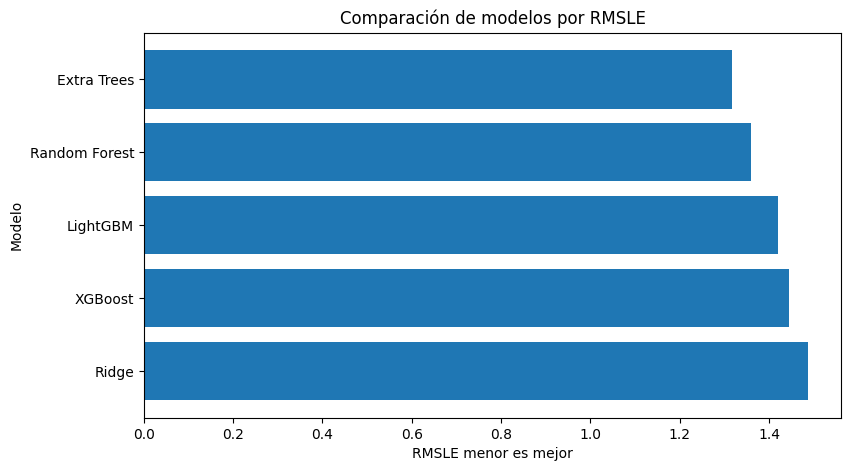

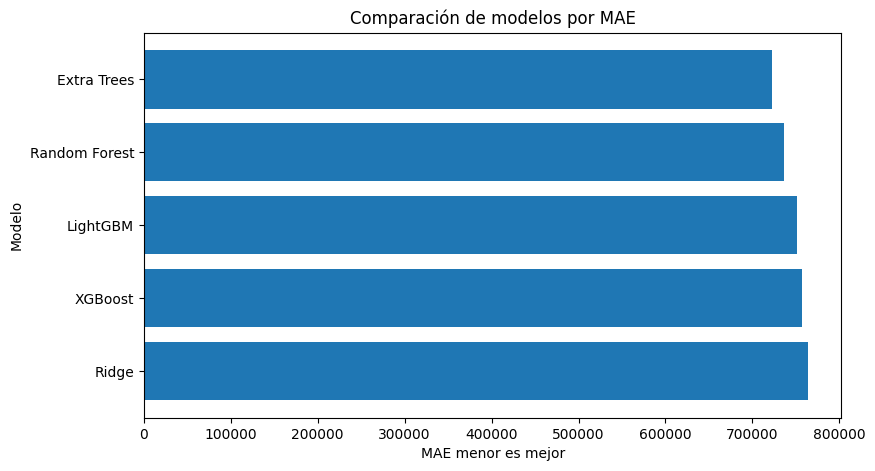

In [11]:
# Comparación visual de modelos por RMSLE.
plot_df = results_df.reset_index().sort_values("RMSLE", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Model"], plot_df["RMSLE"])
ax.invert_yaxis()
ax.set_title("Comparación de modelos por RMSLE")
ax.set_xlabel("RMSLE menor es mejor")
ax.set_ylabel("Modelo")
plt.show()

# MAE ayuda a leer el error promedio en dólares.
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Model"], plot_df["MAE"])
ax.invert_yaxis()
ax.set_title("Comparación de modelos por MAE")
ax.set_xlabel("MAE menor es mejor")
ax.set_ylabel("Modelo")
plt.show()


## 9. Diagnóstico del mejor modelo

Después de elegir el mejor modelo, no basta con ver la tabla de métricas. También conviene revisar ejemplos de predicción y errores grandes.

En esta sección creamos una tabla con:

- `Income_real`: valor real del ingreso.
- `Income_predicho`: predicción del modelo.
- `Error_absoluto`: diferencia absoluta entre real y predicho.
- `Error_porcentual`: error relativo respecto al ingreso real.

Los errores más grandes suelen aparecer en observaciones con ingresos extremos. Esto es normal en problemas donde el target tiene una cola muy larga.


In [12]:
# =============================
# 9. Diagnóstico del mejor modelo
# =============================
comparison_df = pd.DataFrame(
    {
        "Income_real": y_test,
        "Income_predicho": best_pred,
    }
)

# Errores por observación.
comparison_df["Error_absoluto"] = (comparison_df["Income_real"] - comparison_df["Income_predicho"]).abs()
comparison_df["Error_porcentual"] = comparison_df["Error_absoluto"] / comparison_df["Income_real"].replace(0, np.nan)

print("Muestra de predicciones del mejor modelo:")
display(comparison_df.sample(10, random_state=RANDOM_STATE).sort_index())

print("10 mayores errores absolutos:")
display(comparison_df.sort_values("Error_absoluto", ascending=False).head(10))

Muestra de predicciones del mejor modelo:


,Income_real,Income_predicho,Error_absoluto,Error_porcentual
379,74066,"141,297.2774","67,231.2774",0.9077
567,65528,"410,449.6032","344,921.6032",5.2637
1897,75392,"487,853.8522","412,461.8522",5.4709
3791,69992,"348,590.9098","278,598.9098",3.9804
4181,665613,"204,919.0173","460,693.9827",0.6921
6855,72250,"199,674.8699","127,424.8699",1.7637
7565,71576,"70,536.7755","1,039.2245",0.0145
7576,68810,"158,595.7007","89,785.7007",1.3048
8301,872400,"105,462.9783","766,937.0217",0.8791
8976,67120,"213,427.6869","146,307.6869",2.1798


10 mayores errores absolutos:


,Income_real,Income_predicho,Error_absoluto,Error_porcentual
7059,9247992,"155,455.4194","9,092,536.5806",0.9832
7639,9603425,"533,507.6481","9,069,917.3519",0.9444
3442,9110524,"149,873.9603","8,960,650.0397",0.9835
2519,9000568,"224,992.5155","8,775,575.4845",0.9750
7797,8836793,"145,821.8019","8,690,971.1981",0.9835
3917,9060902,"405,448.4354","8,655,453.5646",0.9553
4604,8717226,"96,392.2868","8,620,833.7132",0.9889
4304,8856462,"239,365.2283","8,617,096.7717",0.9730
2606,8720767,"136,614.2593","8,584,152.7407",0.9843
2043,8776380,"232,390.1629","8,543,989.8371",0.9735



### Gráficas de diagnóstico

Las siguientes gráficas trabajan en escala logarítmica.

- En **real vs predicho**, una predicción perfecta estaría sobre la línea diagonal.
- En **residuos log**, valores cerca de cero indican errores pequeños en escala logarítmica.

Se usa escala log porque permite observar mejor el comportamiento general sin que los ingresos extremos aplasten visualmente el resto de los datos.


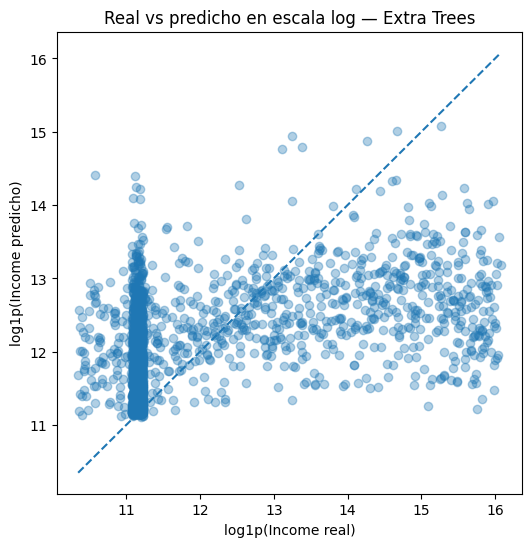

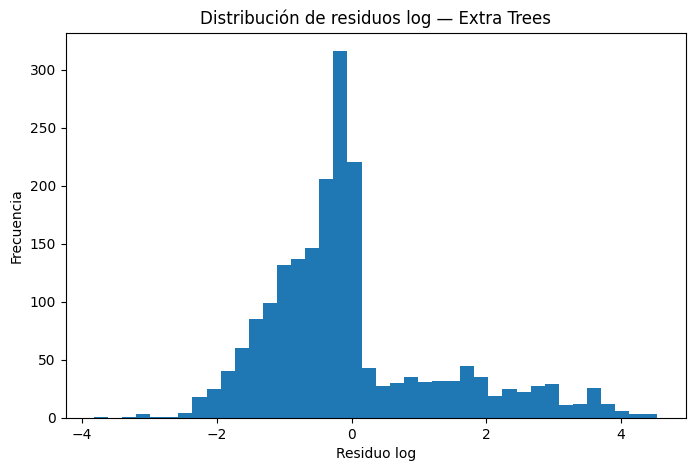

In [13]:
# Real vs predicho en escala logarítmica.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log1p(y_test), np.log1p(best_pred), alpha=0.35)
lims = [min(np.log1p(y_test).min(), np.log1p(best_pred).min()), max(np.log1p(y_test).max(), np.log1p(best_pred).max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title(f"Real vs predicho en escala log — {best_model_name}")
ax.set_xlabel("log1p(Income real)")
ax.set_ylabel("log1p(Income predicho)")
plt.show()

# Distribución de residuos en escala log.
residuals_log = np.log1p(y_test) - np.log1p(best_pred)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals_log, bins=40)
ax.set_title(f"Distribución de residuos log — {best_model_name}")
ax.set_xlabel("Residuo log")
ax.set_ylabel("Frecuencia")
plt.show()


## 10. Importancia de variables

La importancia de variables ayuda a interpretar qué columnas influyeron más en el modelo ganador.

Para modelos de árboles, `feature_importances_` mide cuánto contribuye cada variable a reducir la impureza en las divisiones de los árboles. Para modelos lineales, se usan coeficientes absolutos.

Hay que interpretar esto con cuidado:

- Importancia alta significa que la variable fue útil para predecir.
- No significa causalidad.
- En variables categóricas, One-Hot Encoding divide una variable original en varias columnas, por ejemplo `Occupation_Finance` o `Employment_Status_Part-time`.


Top 20 variables para Extra Trees:


,feature,importance
0,num__Work_Experience,0.0560
1,cat__Employment_Status_Part-time,0.0531
2,num__Number_of_Dependents,0.0501
3,cat__Type_of_Housing_Apartment,0.0431
4,cat__Occupation_Finance,0.0427
5,cat__Education_Level_High School,0.0390
6,cat__Occupation_Technology,0.0386
7,cat__Occupation_Healthcare,0.0353
8,cat__Occupation_Education,0.0333
9,cat__Homeownership_Status_Rent,0.0313


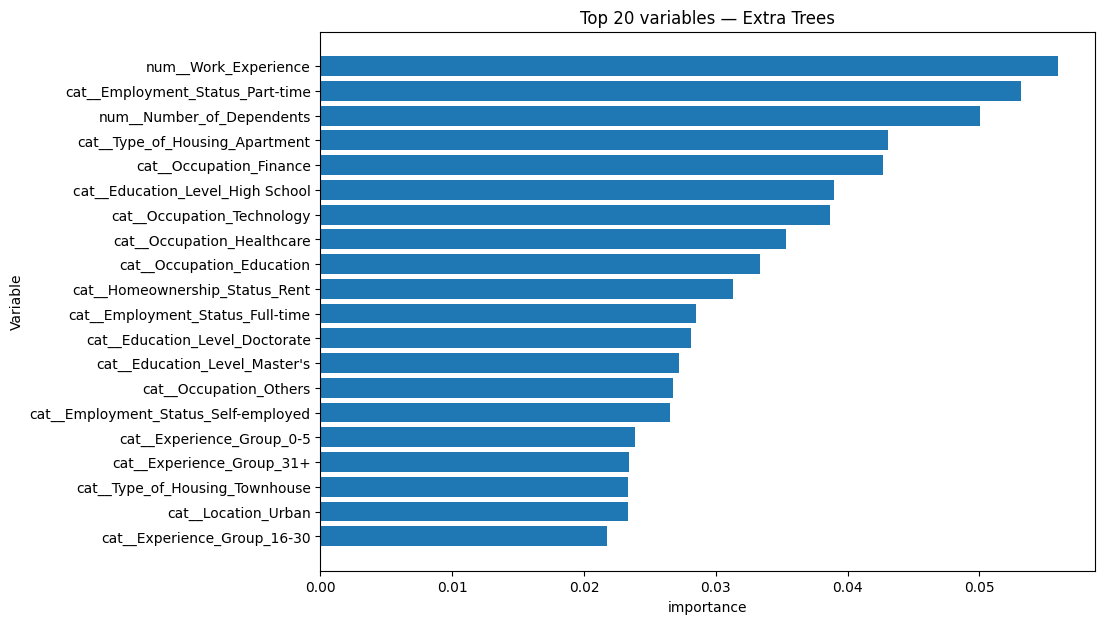

In [14]:
# =============================
# 10. Importancia de variables
# =============================
def get_feature_names_from_pipeline(model):
    fitted_pipeline = model.regressor_
    return fitted_pipeline.named_steps["preprocess"].get_feature_names_out()


def get_feature_importance(model):
    fitted_pipeline = model.regressor_
    fitted_regressor = fitted_pipeline.named_steps["model"]
    feature_names = get_feature_names_from_pipeline(model)

    # Árboles y boosting suelen exponer feature_importances_.
    if hasattr(fitted_regressor, "feature_importances_"):
        values = fitted_regressor.feature_importances_
        importance_type = "importance"
    # Modelos lineales exponen coeficientes.
    elif hasattr(fitted_regressor, "coef_"):
        values = np.abs(np.ravel(fitted_regressor.coef_))
        importance_type = "abs_coefficient"
    else:
        return None, None

    importance_df = (
        pd.DataFrame({"feature": feature_names, importance_type: values})
        .sort_values(importance_type, ascending=False)
        .reset_index(drop=True)
    )
    return importance_df, importance_type


importance_df, importance_col = get_feature_importance(best_model)

if importance_df is None:
    print(f"El modelo {best_model_name} no expone importancia de variables directamente.")
else:
    print(f"Top 20 variables para {best_model_name}:")
    display(importance_df.head(20))

    top_importance = importance_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_importance["feature"], top_importance[importance_col])
    ax.set_title(f"Top 20 variables — {best_model_name}")
    ax.set_xlabel(importance_col)
    ax.set_ylabel("Variable")
    plt.show()


### Lectura de la importancia de variables

En la ejecución incluida, algunas de las variables más influyentes fueron experiencia laboral, estado laboral, número de dependientes, tipo de vivienda, ocupación y educación.

Esto tiene sentido para el problema: el ingreso suele estar relacionado con condiciones laborales, capital educativo, composición del hogar y contexto de vivienda. Aun así, el modelo solo encuentra asociaciones dentro del dataset; no prueba que una variable cause directamente un mayor o menor ingreso.



## 11. Diagrama de arquitectura del modelo ganador: Extra Trees

En esta sección generamos un diagrama explicativo de la arquitectura usada por el mejor modelo. Esta figura es creada con la librería `matplotlib`.

Para el póster científico decidimos que conviene mostrar el flujo completo del modelo que los 300 árboles de forma individual, ya que el ensamble completo sería ilegible y difícil de comprender.

Este diagrama resume:

1. Entrada del dataset.
2. Limpieza e ingeniería de variables.
3. División train/test.
4. Preprocesamiento de `X`.
5. Transformación logarítmica de `y`.
6. Ensamble `ExtraTreesRegressor`.
7. Predicción final y métricas.

Además, se agrega un árbol individual truncado solo como ejemplo de una unidad interna del ensamble.


,Componente,Detalle
0,Modelo ganador,Extra Trees
1,Tipo de arquitectura,Pipeline supervisado de regresión con ensamble...
2,Transformación del target,log1p(Income) durante entrenamiento; expm1(pre...
3,Variables originales + derivadas,6 numéricas y 11 categóricas antes del One-Hot
4,Variables transformadas,45 columnas después del ColumnTransformer
5,Árboles del ensamble,300
6,Profundidad máxima,14
7,Muestras mínimas por hoja,8
8,Variables consideradas por split,0.8000
9,Bootstrap,False


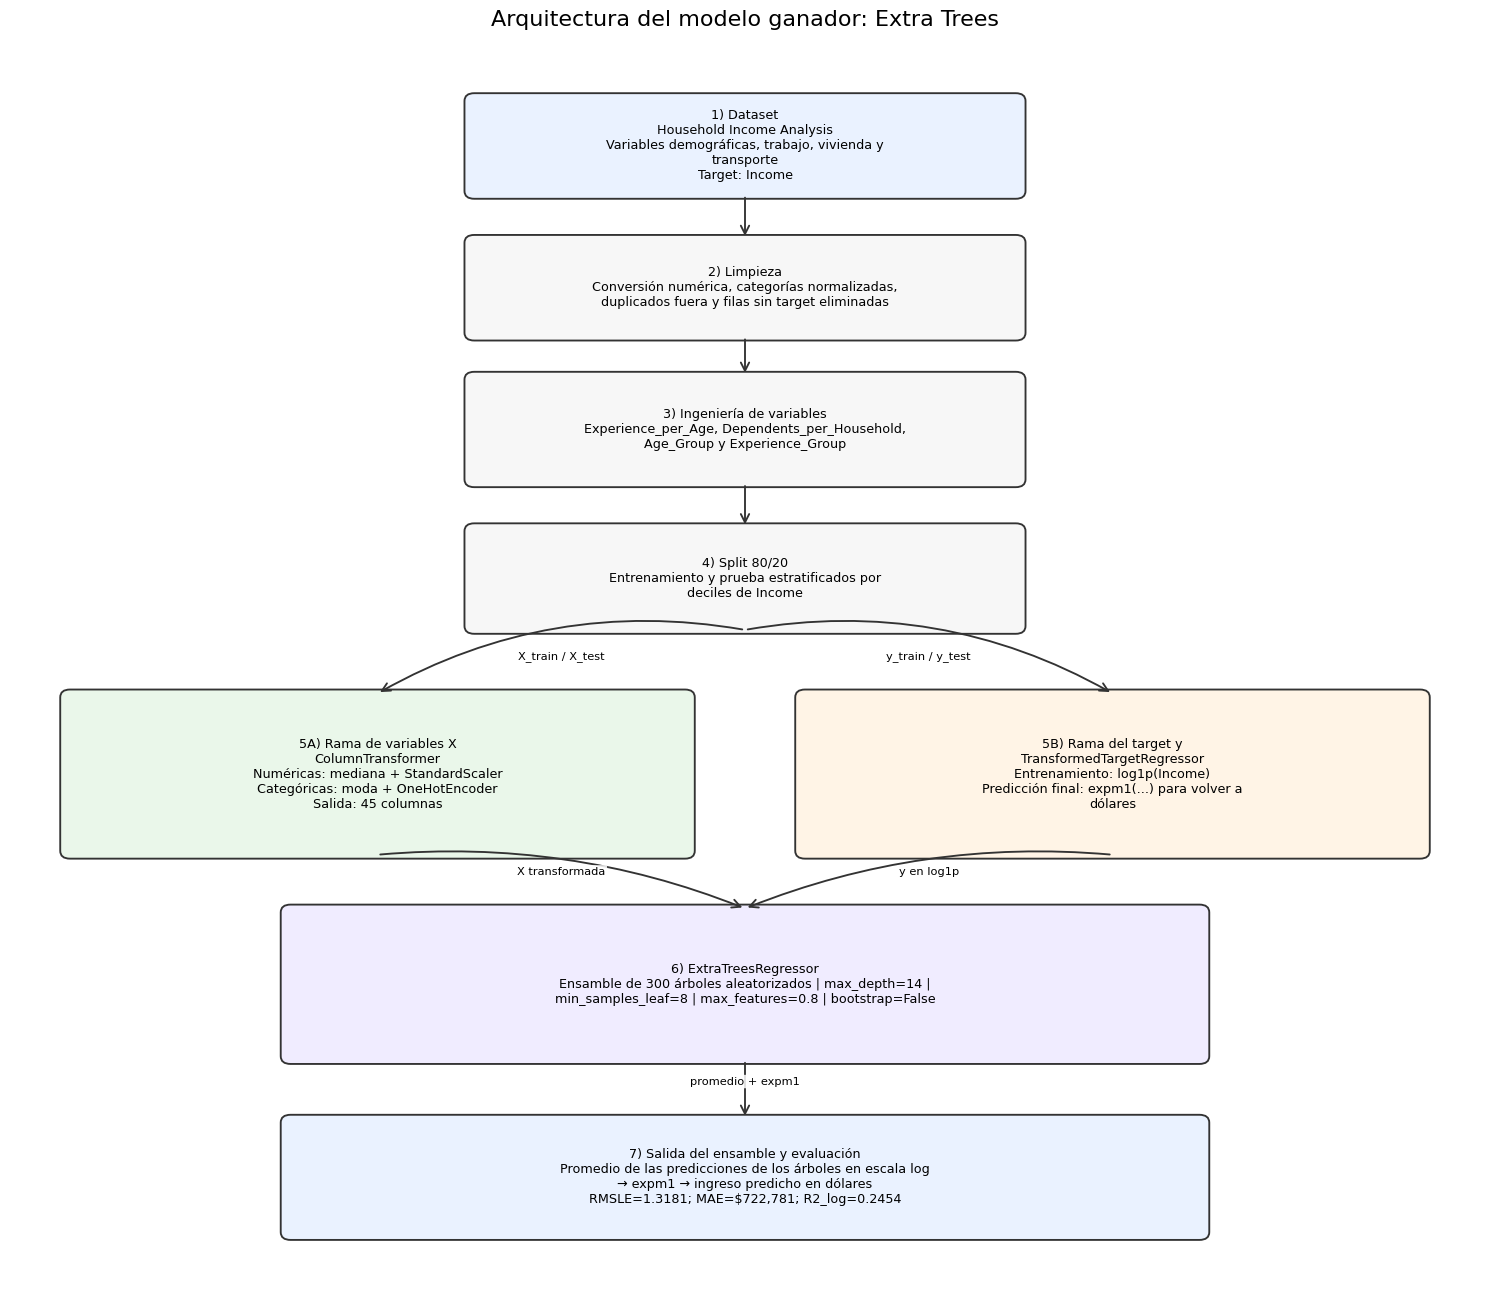

Diagrama guardado por esta celda como: extra_trees_architecture_diagram.png


In [15]:
# =============================
# 11. Diagrama de arquitectura del modelo ganador
# =============================
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display

# Esta celda también funciona si se ejecuta sola, siempre que exista el .joblib guardado.
# Así el diagrama puede regenerarse sin reentrenar todos los modelos.
try:
    best_model_name
    best_model
except NameError:
    from joblib import load

    artifact_path = Path("best_household_income_model.joblib")
    if not artifact_path.exists():
        artifact_path = Path("/mnt/data/best_household_income_model.joblib")

    artifact = load(artifact_path)
    best_model_name = artifact["best_model_name"]
    best_model = artifact["model"]
    numeric_features = artifact.get("numeric_features", [])
    categorical_features = artifact.get("categorical_features", [])
    results_df = artifact.get("metrics", None)

fitted_pipeline = best_model.regressor_
fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
fitted_estimator = fitted_pipeline.named_steps["model"]
feature_names_out = fitted_preprocessor.get_feature_names_out()
model_params = fitted_estimator.get_params()

if best_model_name != "Extra Trees":
    print(
        f"Nota: en esta ejecución el mejor modelo fue {best_model_name}. "
        "El diagrama se construye dinámicamente para el modelo ganador actual."
    )

n_trees = len(getattr(fitted_estimator, "estimators_", [])) or model_params.get("n_estimators", "N/D")
numeric_count = len(numeric_features) if "numeric_features" in globals() else "N/D"
categorical_count = len(categorical_features) if "categorical_features" in globals() else "N/D"
transformed_count = len(feature_names_out)

if "results_df" in globals() and results_df is not None and best_model_name in results_df.index:
    best_metrics = results_df.loc[best_model_name]
    metric_line = (
        f"RMSLE={best_metrics['RMSLE']:.4f}; "
        f"MAE=${best_metrics['MAE']:,.0f}; "
        f"R2_log={best_metrics['R2_log']:.4f}"
    )
else:
    metric_line = "Métricas calculadas en la sección de evaluación"

architecture_summary = pd.DataFrame(
    [
        ["Modelo ganador", best_model_name],
        ["Tipo de arquitectura", "Pipeline supervisado de regresión con ensamble Extra Trees"],
        ["Transformación del target", "log1p(Income) durante entrenamiento; expm1(predicción) para volver a dólares"],
        ["Variables originales + derivadas", f"{numeric_count} numéricas y {categorical_count} categóricas antes del One-Hot"],
        ["Variables transformadas", f"{transformed_count} columnas después del ColumnTransformer"],
        ["Árboles del ensamble", n_trees],
        ["Profundidad máxima", model_params.get("max_depth", "N/D")],
        ["Muestras mínimas por hoja", model_params.get("min_samples_leaf", "N/D")],
        ["Variables consideradas por split", model_params.get("max_features", "N/D")],
        ["Bootstrap", model_params.get("bootstrap", "N/D")],
        ["Resultado de evaluación", metric_line],
    ],
    columns=["Componente", "Detalle"],
)

display(architecture_summary)


def wrap_label(text, width=42):
    """Envuelve texto manteniendo saltos de línea manuales."""
    lines = []
    for part in str(text).split("\n"):
        lines.extend(textwrap.wrap(part, width=width) if part else [""])
    return "\n".join(lines)


def add_box(ax, boxes, key, x, y, w, h, title, body, facecolor="#F8F9FA", width=42):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        linewidth=1.35,
        edgecolor="#333333",
        facecolor=facecolor,
    )
    ax.add_patch(box)
    label = f"{title}\n{body}" if body else title
    ax.text(
        x + w / 2,
        y + h / 2,
        wrap_label(label, width=width),
        ha="center",
        va="center",
        fontsize=9.2,
    )
    boxes[key] = (x, y, w, h)


def anchor(box, side):
    x, y, w, h = box
    if side == "left":
        return x, y + h / 2
    if side == "right":
        return x + w, y + h / 2
    if side == "top":
        return x + w / 2, y + h
    if side == "bottom":
        return x + w / 2, y
    return x + w / 2, y + h / 2


def add_arrow(ax, boxes, start, end, start_side="bottom", end_side="top", label=None, rad=0.0, label_offset=0.12):
    start_point = anchor(boxes[start], start_side)
    end_point = anchor(boxes[end], end_side)
    arrow = FancyArrowPatch(
        start_point,
        end_point,
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.35,
        color="#333333",
        connectionstyle=f"arc3,rad={rad}",
    )
    ax.add_patch(arrow)
    if label:
        mid_x = (start_point[0] + end_point[0]) / 2
        mid_y = (start_point[1] + end_point[1]) / 2
        ax.text(
            mid_x,
            mid_y + label_offset,
            label,
            ha="center",
            va="center",
            fontsize=8.2,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
        )


fig, ax = plt.subplots(figsize=(15, 13))
ax.set_xlim(0, 12)
ax.set_ylim(0, 12.6)
ax.axis("off")

boxes = {}
center_x = 3.75
main_w = 4.5

# Flujo principal de arriba hacia abajo. Cada caja representa una etapa del pipeline.
add_box(
    ax,
    boxes,
    "dataset",
    center_x,
    11.1,
    main_w,
    1.00,
    "1) Dataset",
    "Household Income Analysis\nVariables demográficas, trabajo, vivienda y transporte\nTarget: Income",
    "#EAF2FF",
    width=46,
)
add_box(
    ax,
    boxes,
    "cleaning",
    center_x,
    9.65,
    main_w,
    1.00,
    "2) Limpieza",
    "Conversión numérica, categorías normalizadas, duplicados fuera y filas sin target eliminadas",
    "#F7F7F7",
    width=46,
)
add_box(
    ax,
    boxes,
    "features",
    center_x,
    8.15,
    main_w,
    1.10,
    "3) Ingeniería de variables",
    "Experience_per_Age, Dependents_per_Household, Age_Group y Experience_Group",
    "#F7F7F7",
    width=46,
)
add_box(
    ax,
    boxes,
    "split",
    center_x,
    6.65,
    main_w,
    1.05,
    "4) Split 80/20",
    "Entrenamiento y prueba estratificados por deciles de Income",
    "#F7F7F7",
    width=46,
)

# Ramas paralelas: X son variables predictoras; y es el target Income.
add_box(
    ax,
    boxes,
    "preprocess",
    0.45,
    4.35,
    5.10,
    1.65,
    "5A) Rama de variables X",
    f"ColumnTransformer\nNuméricas: mediana + StandardScaler\nCategóricas: moda + OneHotEncoder\nSalida: {transformed_count} columnas",
    "#EAF7EA",
    width=42,
)
add_box(
    ax,
    boxes,
    "target",
    6.45,
    4.35,
    5.10,
    1.65,
    "5B) Rama del target y",
    "TransformedTargetRegressor\nEntrenamiento: log1p(Income)\nPredicción final: expm1(...) para volver a dólares",
    "#FFF4E6",
    width=42,
)

# Las dos ramas se unen en el modelo entrenado.
add_box(
    ax,
    boxes,
    "model",
    2.25,
    2.25,
    7.50,
    1.55,
    "6) ExtraTreesRegressor",
    f"Ensamble de {n_trees} árboles aleatorizados | max_depth={model_params.get('max_depth', 'N/D')} | min_samples_leaf={model_params.get('min_samples_leaf', 'N/D')} | max_features={model_params.get('max_features', 'N/D')} | bootstrap={model_params.get('bootstrap', 'N/D')}",
    "#F0ECFF",
    width=58,
)
add_box(
    ax,
    boxes,
    "output",
    2.25,
    0.45,
    7.50,
    1.20,
    "7) Salida del ensamble y evaluación",
    f"Promedio de las predicciones de los árboles en escala log → expm1 → ingreso predicho en dólares\n{metric_line}",
    "#EAF2FF",
    width=58,
)

# Flechas del flujo completo del experimento.
add_arrow(ax, boxes, "dataset", "cleaning")
add_arrow(ax, boxes, "cleaning", "features")
add_arrow(ax, boxes, "features", "split")
add_arrow(ax, boxes, "split", "preprocess", label="X_train / X_test", rad=0.18, label_offset=0.05)
add_arrow(ax, boxes, "split", "target", label="y_train / y_test", rad=-0.18, label_offset=0.05)
add_arrow(ax, boxes, "preprocess", "model", label="X transformada", rad=-0.12, label_offset=0.10)
add_arrow(ax, boxes, "target", "model", label="y en log1p", rad=0.12, label_offset=0.10)
add_arrow(ax, boxes, "model", "output", label="promedio + expm1", rad=0.0, label_offset=0.08)

ax.set_title(
    f"Arquitectura del modelo ganador: {best_model_name}",
    fontsize=16,
    pad=16,
)

plt.tight_layout()
fig.savefig("extra_trees_architecture_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Diagrama guardado por esta celda como: extra_trees_architecture_diagram.png")


### Árbol individual representativo del ensamble

Extra Trees no es un solo árbol, sino un ensamble. Cada árbol aprende reglas diferentes porque el algoritmo introduce aleatoriedad en la selección de variables y puntos de corte.

Por esto mismo, el siguiente árbol truncado sirve solo para mostrar cómo se ve una unidad interna del modelo.

Los valores internos del árbol están en escala `log1p(Income)`, porque el target se transformó durante el entrenamiento.


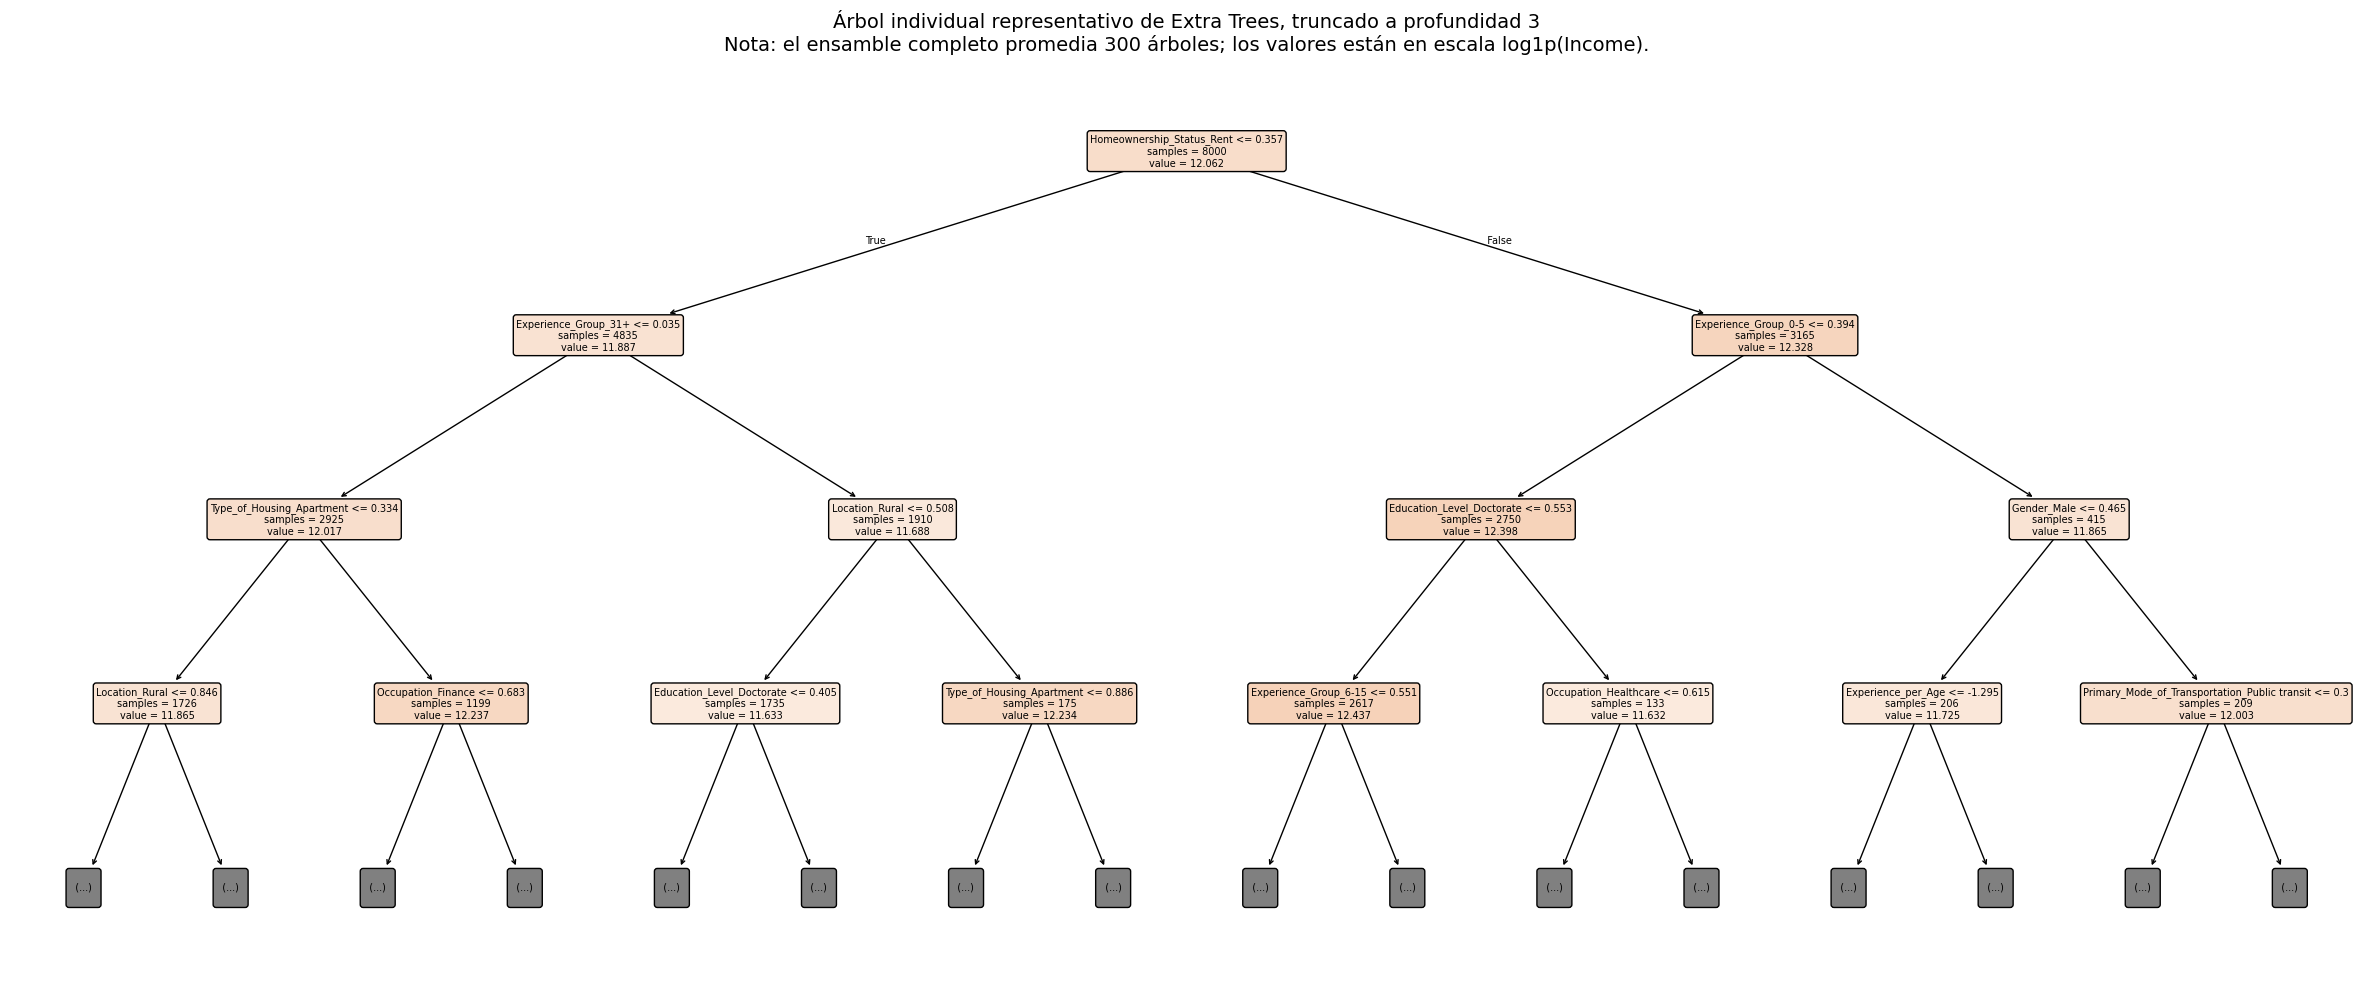

Árbol representativo guardado por esta celda como: extra_trees_arbol_representativo_depth3.png


In [16]:
# =============================
# 11b. Árbol individual representativo del ensamble Extra Trees
# =============================
from sklearn.tree import plot_tree

if not hasattr(fitted_estimator, "estimators_"):
    print(f"El modelo {best_model_name} no expone árboles individuales para graficar.")
else:
    # Mostramos solo un árbol y solo hasta profundidad 3 para que sea legible.
    example_tree = fitted_estimator.estimators_[0]
    readable_feature_names = [
        str(name).replace("num__", "").replace("cat__", "")
        for name in feature_names_out
    ]

    fig, ax = plt.subplots(figsize=(24, 10))
    plot_tree(
        example_tree,
        max_depth=3,
        feature_names=readable_feature_names,
        filled=True,
        rounded=True,
        impurity=False,
        fontsize=7,
        ax=ax,
    )
    ax.set_title(
        "Árbol individual representativo de Extra Trees, truncado a profundidad 3\n"
        "Nota: el ensamble completo promedia 300 árboles; los valores están en escala log1p(Income).",
        fontsize=14,
    )
    plt.tight_layout()
    fig.savefig("extra_trees_arbol_representativo_depth3.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Árbol representativo guardado por esta celda como: extra_trees_arbol_representativo_depth3.png")


## 12. Búsqueda opcional de hiperparámetros

La siguiente celda está desactivada por defecto para que el notebook corra rápido.

Si en dado caso queremos mejorar el desempeño, podemos cambiar:

```python
RUN_TUNING = True
```

y volvemos a ejecutar la celda.

La búsqueda usa `RandomizedSearchCV`, que prueba combinaciones aleatorias de parámetros dentro de rangos definidos. Es más eficiente que probar todas las combinaciones posibles. En este caso lo hacemos de esta manera ya que realmente no es un proyecto extremadamente grande.


In [17]:
# =============================
# 12. Tuning opcional
# =============================
RUN_TUNING = False

if RUN_TUNING:
    from sklearn.model_selection import RandomizedSearchCV, KFold

    # Scikit-learn maximiza scores; por eso se usa greater_is_better=False.
    rmsle_scorer = make_scorer(rmsle, greater_is_better=False)
    cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    # Espacios de búsqueda por modelo.
    param_spaces = {
        "Ridge": {
            "regressor__model__alpha": [0.1, 1, 3, 10, 30, 100, 300],
        },
        "Random Forest": {
            "regressor__model__n_estimators": [200, 400, 600],
            "regressor__model__max_depth": [8, 12, 16, None],
            "regressor__model__min_samples_leaf": [5, 8, 10, 15],
            "regressor__model__max_features": ["sqrt", 0.5, 0.7, 1.0],
        },
        "Extra Trees": {
            "regressor__model__n_estimators": [200, 400, 600],
            "regressor__model__max_depth": [10, 14, 18, None],
            "regressor__model__min_samples_leaf": [3, 5, 8, 10],
            "regressor__model__max_features": ["sqrt", 0.5, 0.8, 1.0],
        },
        "XGBoost": {
            "regressor__model__n_estimators": [200, 300, 500],
            "regressor__model__learning_rate": [0.01, 0.03, 0.05],
            "regressor__model__max_depth": [2, 3, 4],
            "regressor__model__min_child_weight": [5, 10, 20],
            "regressor__model__reg_lambda": [5, 10, 20, 40],
        },
        "LightGBM": {
            "regressor__model__n_estimators": [200, 300, 500],
            "regressor__model__learning_rate": [0.01, 0.03, 0.05],
            "regressor__model__num_leaves": [7, 15, 31],
            "regressor__model__min_child_samples": [20, 40, 80],
            "regressor__model__reg_lambda": [1, 5, 10, 20],
        },
        "Gradient Boosting": {
            "regressor__model__n_estimators": [200, 300, 500],
            "regressor__model__learning_rate": [0.01, 0.03, 0.05],
            "regressor__model__max_depth": [2, 3],
            "regressor__model__min_samples_leaf": [10, 20, 40],
        },
        "AdaBoost": {
            "regressor__model__n_estimators": [100, 200, 300],
            "regressor__model__learning_rate": [0.01, 0.03, 0.1],
        },
    }

    tuned_models = OrderedDict()
    tuning_rows = []

    for name, model in models.items():
        params = param_spaces.get(name, {})
        if not params:
            tuned_models[name] = model
            continue

        total_grid = int(np.prod([len(v) for v in params.values()]))
        n_iter = min(15, total_grid)

        print(f"Tuning {name} con {n_iter} combinaciones...")
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=n_iter,
            scoring=rmsle_scorer,
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=1,
        )
        search.fit(X_train, y_train)
        tuned_models[name] = search.best_estimator_
        tuning_rows.append(
            {
                "Model": name,
                "Best_CV_RMSLE": -search.best_score_,
                "Best_Params": search.best_params_,
            }
        )

    tuning_results = pd.DataFrame(tuning_rows).sort_values("Best_CV_RMSLE")
    display(tuning_results)
else:
    print("Tuning omitido. Cambia RUN_TUNING = True para ejecutarlo.")

Tuning omitido. Cambia RUN_TUNING = True para ejecutarlo.



## 13. Guardar el mejor modelo

El modelo se guarda con `joblib` en un archivo `.joblib`.

Se guarda un diccionario que incluye:

- Nombre del mejor modelo.
- Pipeline completo entrenado.
- Lista de variables usadas.
- Variables numéricas y categóricas.
- Tabla de métricas.

Esto es útil porque el archivo no guarda solo el regresor. También conserva el preprocesamiento y la transformación del target, por lo que puede reutilizarse de manera consistente.


In [18]:
# =============================
# 13. Guardado del mejor modelo
# =============================
model_artifact = {
    "best_model_name": best_model_name,
    "model": best_model,
    "features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": results_df,
}

output_model_path = Path("best_household_income_model.joblib")
dump(model_artifact, output_model_path)
print(f"Modelo guardado en: {output_model_path.resolve()}")

Modelo guardado en: /content/best_household_income_model.joblib



## Conclusiones generales

1. **Extra Trees fue el mejor modelo.**  
   Obtuvo el menor `RMSLE`, por lo que fue seleccionado como modelo ganador debido al desempeño obtenido.

2. **La transformación logarítmica fue necesaria.**  
   `Income` tiene una distribución muy sesgada, con valores extremos. Entrenar sobre `log1p(Income)` hizo que el modelo aprendiera mejor diferencias relativas.

3. **Los modelos basados en árboles fueron más adecuados que el modelo lineal.**  
   Ridge funcionó como baseline, pero no logró capturar tan bien las relaciones no lineales del dataset.

4. **Las variables laborales y socioeconómicas fueron relevantes.**  
   Experiencia laboral, estado laboral, ocupación, educación, número de dependientes y vivienda aparecieron entre las variables más importantes.

5. **El ingreso es difícil de predecir en escala monetaria real.**  
   Aunque Extra Trees fue el mejor, los errores en dólares siguen siendo altos por la presencia de ingresos extremadamente grandes.

## Limitaciones del proyecto

- El análisis es predictivo, no causal.
- El dataset puede no representar completamente escenarios reales.
- El modelo se evaluó principalmente con una división train/test 80/20.
- Los valores extremos afectan fuertemente métricas como `RMSE` y `R2_real`.
- Las importancias de variables pueden dividirse entre muchas columnas debido al One-Hot Encoding.

## Mejoras futuras

- Ejecutar tuning más amplio de hiperparámetros.
- Aplicar validación cruzada repetida.
- Analizar errores por rangos de ingreso.
- Probar tratamiento de outliers o winsorización.
- Evaluar modelos adicionales como CatBoost o regresión por cuantiles.
- Usar SHAP o Permutation Importance para mejorar interpretabilidad.
- Validar el modelo con otro dataset o con datos reales.
- Crear una aplicación web o PWA que use el `.joblib` para realizar predicciones.